# Tech Challenge - Fase 1

## Desafio

Um grande hospital universitário busca implementar um sistema inteligente de suporte ao diagnóstico, capaz de ajudar médicos e equipes clínicas na análise inicial de exames e no processamento de dados médicos.

Com um volume crescente de pacientes e exames, como radiografias, tomografias, ressonâncias e prontuários digitalizados, o hospital precisa de soluções que acelerem a triagem e apoiem as decisões médicas, reduzindo erros e otimizando o tempo dos profissionais.

Nesta primeira fase, o desafio é criar a base do sistema de IA focado em machine learning, permitindo que resultados de exames sejam analisados automaticamente e destacando informações relevantes para o diagnóstico.

## Objetivo

Construir uma solução inicial com foco em IA para processamento de exames médicos e documentos clínicos, aplicando fundamentos essenciais de IA, Machine Learning e Visão Computacional.

## Patologia escolhida para o desafio: Acidente Vascular Cerebral (AVC)

### O que é o AVC

O Acidente Vascular Cerebral (AVC) é uma condição em que o fluxo de sangue para uma parte do cérebro é interrompido. Como as células cerebrais dependem de oxigênio e nutrientes trazidos pelo sangue, essa interrupção pode causar danos neurológicos em poucos minutos.

### Tipos de AVC

1. AVC Isquêmico

- Ocorre quando um vaso sanguíneo é bloqueado por um coágulo.
- É o tipo mais comum.
- Geralmente relacionado a aterosclerose, fibrilação atrial e fatores de risco cardiovasculares.

2. AVC Hemorrágico
- Acontece quando um vaso sanguíneo se rompe, causando sangramento no cérebro.
- Pode ser causado por hipertensão não controlada, aneurismas ou malformações vasculares.

### Base de Dados - NHANES (https://www.cdc.gov/nchs/nhanes)

O NHANES (National Health and Nutrition Examination Survey) é uma base de dados pública conduzida pelo CDC (Centers for Disease Control and Prevention) dos Estados Unidos, voltada à avaliação do estado de saúde e nutricional da população norte-americana.

De forma breve:

- Natureza: estudo observacional, transversal, com amostragem probabilística representativa da população dos EUA.

- Periodicidade: realizado continuamente, organizado em ciclos bienais (ex.: 2017–2018 https://wwwn.cdc.gov/Nchs/Nhanes/continuousnhanes/default.aspx?BeginYear=2017).

- Conteúdo: combina

    - Questionários (doenças autorreferidas, estilo de vida, tabagismo, diabetes, histórico de AVC),

    - Exames físicos (pressão arterial, IMC, medidas corporais),

    - Exames laboratoriais (glicemia, hemoglobina glicada, colesterol, triglicerídeos, marcadores inflamatórios).

- Formato dos dados: arquivos modulares (.XPT), integrados por um identificador único do participante (SEQN).

- Aspecto metodológico importante: inclui pesos amostrais e variáveis de desenho complexo, permitindo inferência populacional.

No contexto acadêmico, o NHANES é amplamente utilizado para modelagem de risco cardiovascular e de AVC, epidemiologia, análise de fatores de risco e aplicações de machine learning em saúde, sendo valorizado pela qualidade dos dados, transparência metodológica e acesso aberto.

**Importando a base de dados**

In [328]:
import pandas as pd  # importa a biblioteca pandas

pd.set_option('display.max_columns', None)  # configura o pandas para mostrar todas as colunas ao exibir DataFrames

import pandas as pd  # importa a biblioteca pandas

pd.set_option('display.max_columns', None)  # configura o pandas para mostrar todas as colunas ao exibir DataFrames

cycle_map = {
    "2011-2012": "G",
    "2013-2014": "H",
    "2015-2016": "I",
    "2017-2018": "J"
}

modules = {  # dicionário que mapeia nomes lógicos para templates de arquivos XPT
    "demo": "DEMO_{}.XPT",  # arquivo DEMO (dados demográficos): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.htm (ajustado para usar a letra do ciclo)
    "bpx": "BPX_{}.XPT",     # arquivo BPX (medidas de pressão arterial): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPX_J.htm
    "bpq": "BPQ_{}.XPT", # arquivo BPQ (pressão arterial e colesterol): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPQ_J.htm
    "ocq": "OCQ_{}.XPT",     # arquivo OCQ (questionário de ocupação): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/OCQ_J.htm
    "ghb": "GHB_{}.XPT",     # arquivo GHB (hemoglobina glicada): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/GHB_J.htm
    "bmx": "BMX_{}.XPT",     # arquivo BMX (medidas corporais): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.htm
    "smq": "SMQ_{}.XPT",     # arquivo SMQ (questionário de tabagismo): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/SMQ_J.htm
    "mcq": "MCQ_{}.XPT"     # arquivo de questionário médico (histórico de doenças): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/MCQ_J.htm
}

dfs = {name: [] for name in modules}  # dicionário de listas para armazenar os DataFrames de cada módulo por ciclo

cycles = list(cycle_map.keys())  # lista de ciclos (ex.: ["2011-2012", "2017-2018"])

for cycle in cycles:
    letter = cycle_map[cycle]  # obtém a letra do ciclo (ex.: "G" para "2011-2012")
    year = cycle.split('-')[0]  # obtém o ano inicial do ciclo (ex.: "2011" para "2011-2012")
    base_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/" + year + "/DataFiles/"  # URL base para os arquivos NHANES, usando o ano inicial
    for name, file_template in modules.items():  # itera sobre (nome, template de arquivo) do dicionário modules
        file = file_template.format(letter)  # formata o template com a letra do ciclo (ex.: "DEMO_G.XPT")
        print(f"Carregando {file} para o ciclo {cycle}...")
        dfs[name].append(pd.read_sas(base_url + file))  # lê o arquivo XPT remoto e adiciona à lista de dfs[name]

# concatena os DataFrames de cada módulo de todos os ciclos
demo_df = pd.concat(dfs["demo"], ignore_index=True)
bpx_df = pd.concat(dfs["bpx"], ignore_index=True)
bpq_df = pd.concat(dfs["bpq"], ignore_index=True)
ocq_df = pd.concat(dfs["ocq"], ignore_index=True)
ghb_df = pd.concat(dfs["ghb"], ignore_index=True)
bmx_df = pd.concat(dfs["bmx"], ignore_index=True)
smq_df = pd.concat(dfs["smq"], ignore_index=True)
mcq_df = pd.concat(dfs["mcq"], ignore_index=True)

# inicia com o DataFrame 'demo' concatenado e faz merges left sucessivos com os outros DataFrames concatenados usando 'SEQN' como chave
df = demo_df \
    .merge(bpx_df, on="SEQN", how="left") \
    .merge(bpq_df, on="SEQN", how="left") \
    .merge(ocq_df, on="SEQN", how="left") \
    .merge(ghb_df, on="SEQN", how="left") \
    .merge(bmx_df, on="SEQN", how="left") \
    .merge(smq_df, on="SEQN", how="left") \
    .merge(mcq_df, on="SEQN", how="left")

df.head()  # exibe a forma (número de linhas e colunas) do DataFrame final combinado


Carregando DEMO_G.XPT para o ciclo 2011-2012...
Carregando BPX_G.XPT para o ciclo 2011-2012...
Carregando BPQ_G.XPT para o ciclo 2011-2012...
Carregando OCQ_G.XPT para o ciclo 2011-2012...
Carregando GHB_G.XPT para o ciclo 2011-2012...
Carregando BMX_G.XPT para o ciclo 2011-2012...
Carregando SMQ_G.XPT para o ciclo 2011-2012...
Carregando MCQ_G.XPT para o ciclo 2011-2012...
Carregando DEMO_H.XPT para o ciclo 2013-2014...
Carregando BPX_H.XPT para o ciclo 2013-2014...
Carregando BPQ_H.XPT para o ciclo 2013-2014...
Carregando OCQ_H.XPT para o ciclo 2013-2014...
Carregando GHB_H.XPT para o ciclo 2013-2014...
Carregando BMX_H.XPT para o ciclo 2013-2014...
Carregando SMQ_H.XPT para o ciclo 2013-2014...
Carregando MCQ_H.XPT para o ciclo 2013-2014...
Carregando DEMO_I.XPT para o ciclo 2015-2016...
Carregando BPX_I.XPT para o ciclo 2015-2016...
Carregando BPQ_I.XPT para o ciclo 2015-2016...
Carregando OCQ_I.XPT para o ciclo 2015-2016...
Carregando GHB_I.XPT para o ciclo 2015-2016...
Carregando

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGY,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGE,DMDHRBR4,DMDHREDU,DMDHRMAR,DMDHSEDU,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,PEASCST1,PEASCTM1,PEASCCT1,BPXCHR,BPQ150A,BPQ150B,BPQ150C,BPQ150D,BPAARM,BPACSZ,BPXPLS,BPXPULS,BPXPTY,BPXML1,BPXSY1,BPXDI1,BPAEN1,BPXSY2,BPXDI2,BPAEN2,BPXSY3,BPXDI3,BPAEN3,BPXSY4,BPXDI4,BPAEN4,BPQ020,BPQ030,BPD035,BPQ040A,BPQ050A,BPQ057,BPQ056,BPD058,BPQ059,BPQ080,BPQ060,BPQ070,BPQ090D,BPQ100D,OCD150,OCQ180,OCQ210,OCD231,OCD241,OCQ260,OCD270,OCQ275,OCQ380,OCD390G,OCD391,OCD392,OCD395,OCQ510,OCQ520,OCQ530,OCQ540,OCQ550,OCQ560,OCQ570,OCQ580,OCQ600,OCQ610,OCQ630,OCQ640,OCQ660,OCQ670,LBXGH,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,BMXBMI,BMDBMIC,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXSAD1,BMXSAD2,BMXSAD3,BMXSAD4,BMDAVSAD,BMDSADCM,BMXHIP,BMIHIP,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD055,SMD057,SMQ077,SMD641,SMD650,SMD093,SMDUPCA,SMD100BR,SMD100FL,SMD100MN,SMD100LN,SMD100TR,SMD100NI,SMD100CO,SMQ621,SMD630,SMQ660,SMQ664M,SMQ664C,SMQ664W,SMQ664B,SMQ664O,SMQ670,SMAQUEX2,SMQ078,SMQ661,SMQ665A,SMQ665B,SMQ665C,SMQ665D,SMQ848,SMQ852Q,SMQ852U,SMQ925,SMQ930,SMQ935,SMQ080,SMQ890,SMQ895,SMQ900,SMQ905,SMQ910,SMQ915,MCQ010,MCQ025,MCQ035,MCQ040,MCQ050,MCQ051,MCQ053,MCQ070,MCQ075,MCQ080,MCQ082,MCQ084,MCQ086,MCQ092,MCD093,MCQ140,MCQ149,MCQ160A,MCQ180A,MCQ195,MCQ160N,MCQ180N,MCQ160B,MCQ180B,MCQ160C,MCQ180C,MCQ160D,MCQ180D,MCQ160E,MCQ180E,MCQ160F,MCQ180F,MCQ160G,MCQ180G,MCQ160M,MCQ170M,MCQ180M,MCQ160K,MCQ170K,MCQ180K,MCQ160L,MCQ170L,MCQ180L,MCQ220,MCQ230A,MCQ230B,MCQ230C,MCQ230D,MCQ240A,MCQ240AA,MCQ240B,MCQ240BB,MCQ240C,MCQ240CC,MCQ240D,MCQ240DD,MCQ240DK,MCQ240E,MCQ240F,MCQ240G,MCQ240H,MCQ240I,MCQ240J,MCQ240K,MCQ240L,MCQ240M,MCQ240N,MCQ240O,MCQ240P,MCQ240Q,MCQ240R,MCQ240S,MCQ240T,MCQ240U,MCQ240V,MCQ240W,MCQ240X,MCQ240Y,MCQ240Z,MCQ300A,MCQ300B,MCQ300C,MCQ365A,MCQ365B,MCQ365C,MCQ365D,MCQ370A,MCQ370B,MCQ370C,MCQ370D,MCQ380,AGQ030,MCQ151,MCQ160O,MCQ203,MCQ206,OSQ230,RHD018,MCD180A,MCD180N,MCD180B,MCD180C,MCD180D,MCD180E,MCD180F,MCD180M,MCD180G,MCD180K,MCD180L,MCQ500,MCQ510A,MCQ510B,MCQ510C,MCQ510D,MCQ510E,MCQ510F,MCQ520,MCQ530,MCQ540,MCQ550,MCQ560,MCQ570,MCD240A,MCD240B,MCD240C,MCQ366A,MCQ366B,MCQ366C,MCQ366D,MCQ371A,MCQ371B,MCQ371C,MCQ371D
0,62161.0,7.0,2.0,1.0,22.0,NaN,3.0,3.0,2.0,NaN,NaN,2.0,NaN,1.0,1.0,NaN,NaN,3.0,5.0,NaN,1.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,102641.406474,104236.582554,1.0,91.0,14.0,14.0,3.15,5.0,5.0,5.397605e-79,1.0,5.397605e-79,2.0,50.0,1.0,5.0,1.0,5.0,NaN,NaN,NaN,NaN,1.0,596.0,NaN,NaN,2.0,2.0,2.0,2.0,1.0,4.0,82.0,1.0,1.0,130.0,110.0,82.0,2.0,104.0,68.0,2.0,118.0,74.0,2.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2.0,2.0,NaN,2.0,2.0,2.0,NaN,NaN,NaN,1.0,99999.0,2.0,16.0,14.0,4.0,12.0,2.0,NaN,2.0,NaN,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,5.1,1.0,69.2,NaN,NaN,NaN,NaN,NaN,172.3,NaN,23.3,NaN,40.2,NaN,35.0,NaN,32.5,NaN,81.0,NaN,17.7,17.9,NaN,NaN,17.8,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b'',b'',NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,2.0,2.0,NaN,2.0,2.0,NaN,2.0,NaN,2.0,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,62162.0,7.0,2.0,2.0,3.0,NaN,1.0,1.0,1.0,3

In [329]:
df.shape

(39156, 328)

In [330]:
# manter somente as colunas solicitadas (se existirem) e avisar se alguma estiver ausente
cols_to_keep = [
    "SEQN", # Respondent sequence number
    "RIAGENDR", # Gender (DEMO): 1 - Male, 2 - Female
    "RIDAGEYR", # Age in years at screening (DEMO): 0 YEARS - 150 YEARS
    "BPQ020", # Ever told you had high blood pressure (BPQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "MCQ160B",  # Ever told had congestive heart failure (MCQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "DMDMARTL", # Marital status (DEMO): 1 - Married, 2 - Widowed, 3 - Divorced, 4 - Separated, 5 - Never married, 6 - Living with partner
    "OCQ260", # Description of job/work situation (OCQ): 1 - An employee of a private company, business, or individual for wages, salary, or commission., 2 - A federal government employee, 3 - A state government employee, 4 - A local government employee, 5 - Self-employed in own business, Working without pay in family business or farm, 6 - Refused, 77 - Don't know, 99 - Refused
    "BPXSY1", # Systolic blood pressure (BPX): 72 to 228 mm Hg
    "LBXGH", # Glycohemoglobin (GHB)
    "BMXBMI", # Body Mass Index (BMX)
    "SMQ020", # Ever smoked a cigar even 1 time? (SMQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "MCQ160F" # TARGET -> Ever told you had a stroke (MCQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
]

missing = [c for c in cols_to_keep if c not in df.columns]
if missing:
    print("Aviso: colunas ausentes e que não foram selecionadas:", missing)

df = df[[c for c in cols_to_keep if c in df.columns]].copy()

# renomeia as colunas usando sufixos descritivos
suffix_descriptions = {
    "SEQN": "id", # Respondent sequence number
    "RIAGENDR": "gender", # Gender
    "RIDAGEYR": "age", # Age in years
    "BPQ020": "high_bp", # High blood pressure
    "MCQ160B": "chf", # Congestive heart failure
    "DMDMARTL": "marital", # Marital status
    "OCQ260": "occupation", # Occupation
    "BPXSY1": "sbp", # Systolic blood pressure
    "LBXGH": "hba1c", # Glycohemoglobin
    "BMXBMI": "bmi", # Body Mass Index
    "SMQ020": "smoking", # Smoking
    "MCQ160F": "stroke" # Ever told you had a stroke
}
rename_map = {c: f"{c}_{suffix_descriptions[c]}" for c in df.columns if c in suffix_descriptions}
df = df.rename(columns=rename_map)
print("Colunas renomeadas:", list(rename_map.values()))
df.shape

Colunas renomeadas: ['SEQN_id', 'RIAGENDR_gender', 'RIDAGEYR_age', 'BPQ020_high_bp', 'MCQ160B_chf', 'DMDMARTL_marital', 'OCQ260_occupation', 'BPXSY1_sbp', 'LBXGH_hba1c', 'BMXBMI_bmi', 'SMQ020_smoking', 'MCQ160F_stroke']


(39156, 12)

**Exploração de dados**

In [331]:
df.head(5)

,SEQN_id,RIAGENDR_gender,RIDAGEYR_age,BPQ020_high_bp,MCQ160B_chf,DMDMARTL_marital,OCQ260_occupation,BPXSY1_sbp,LBXGH_hba1c,BMXBMI_bmi,SMQ020_smoking,MCQ160F_stroke
0,62161.0,1.0,22.0,2.0,2.0,5.0,4.0,110.0,5.1,23.3,2.0,2.0
1,62162.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,14.2,NaN,NaN
2,62163.0,1.0,14.0,NaN,NaN,NaN,NaN,112.0,5.5,17.3,NaN,NaN
3,62164.0,2.0,44.0,2.0,2.0,1.0,1.0,116.0,4.9,23.2,2.0,2.0
4,62165.0,2.0,14.0,NaN,NaN,NaN,NaN,110.0,5.9,27.2,NaN,NaN


In [332]:
# verificar as 20 colunas com mais valores ausentes
df.isnull().sum().sort_values(ascending=False).head(20)

OCQ260_occupation    25844
MCQ160B_chf          16540
MCQ160F_stroke       16540
DMDMARTL_marital     16539
SMQ020_smoking       15636
BPQ020_high_bp       14030
LBXGH_hba1c          13997
BPXSY1_sbp           11781
BMXBMI_bmi            4738
RIDAGEYR_age             0
SEQN_id                  0
RIAGENDR_gender          0
dtype: int64

In [333]:
# calcular o percentual de valores ausentes por coluna
total = len(df)
(df.isnull().sum() / total * 100).sort_values(ascending=False).head(20)

OCQ260_occupation    66.002656
MCQ160B_chf          42.241291
MCQ160F_stroke       42.241291
DMDMARTL_marital     42.238737
SMQ020_smoking       39.932577
BPQ020_high_bp       35.831035
LBXGH_hba1c          35.746757
BPXSY1_sbp           30.087343
BMXBMI_bmi           12.100317
RIDAGEYR_age          0.000000
SEQN_id               0.000000
RIAGENDR_gender       0.000000
dtype: float64

<Axes: >

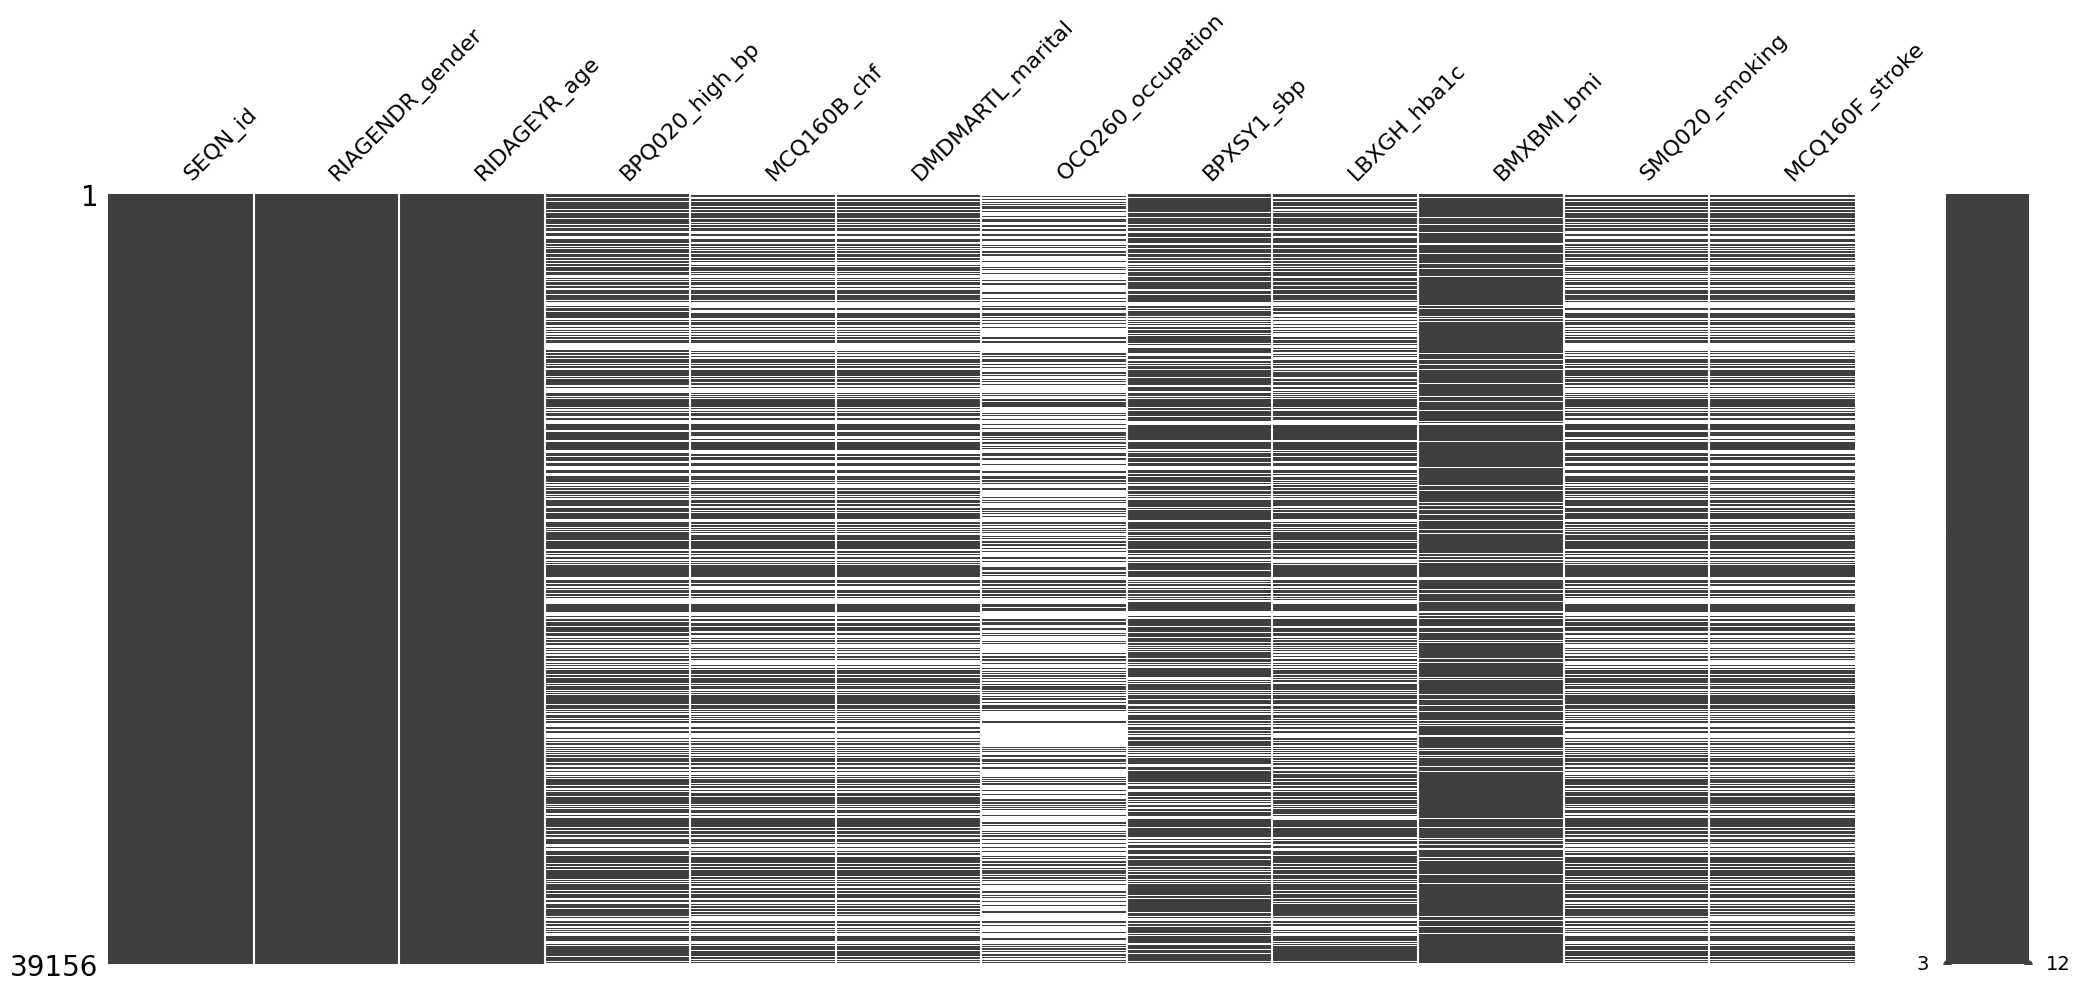

In [334]:
import missingno as msno
msno.matrix(df)

<Axes: >

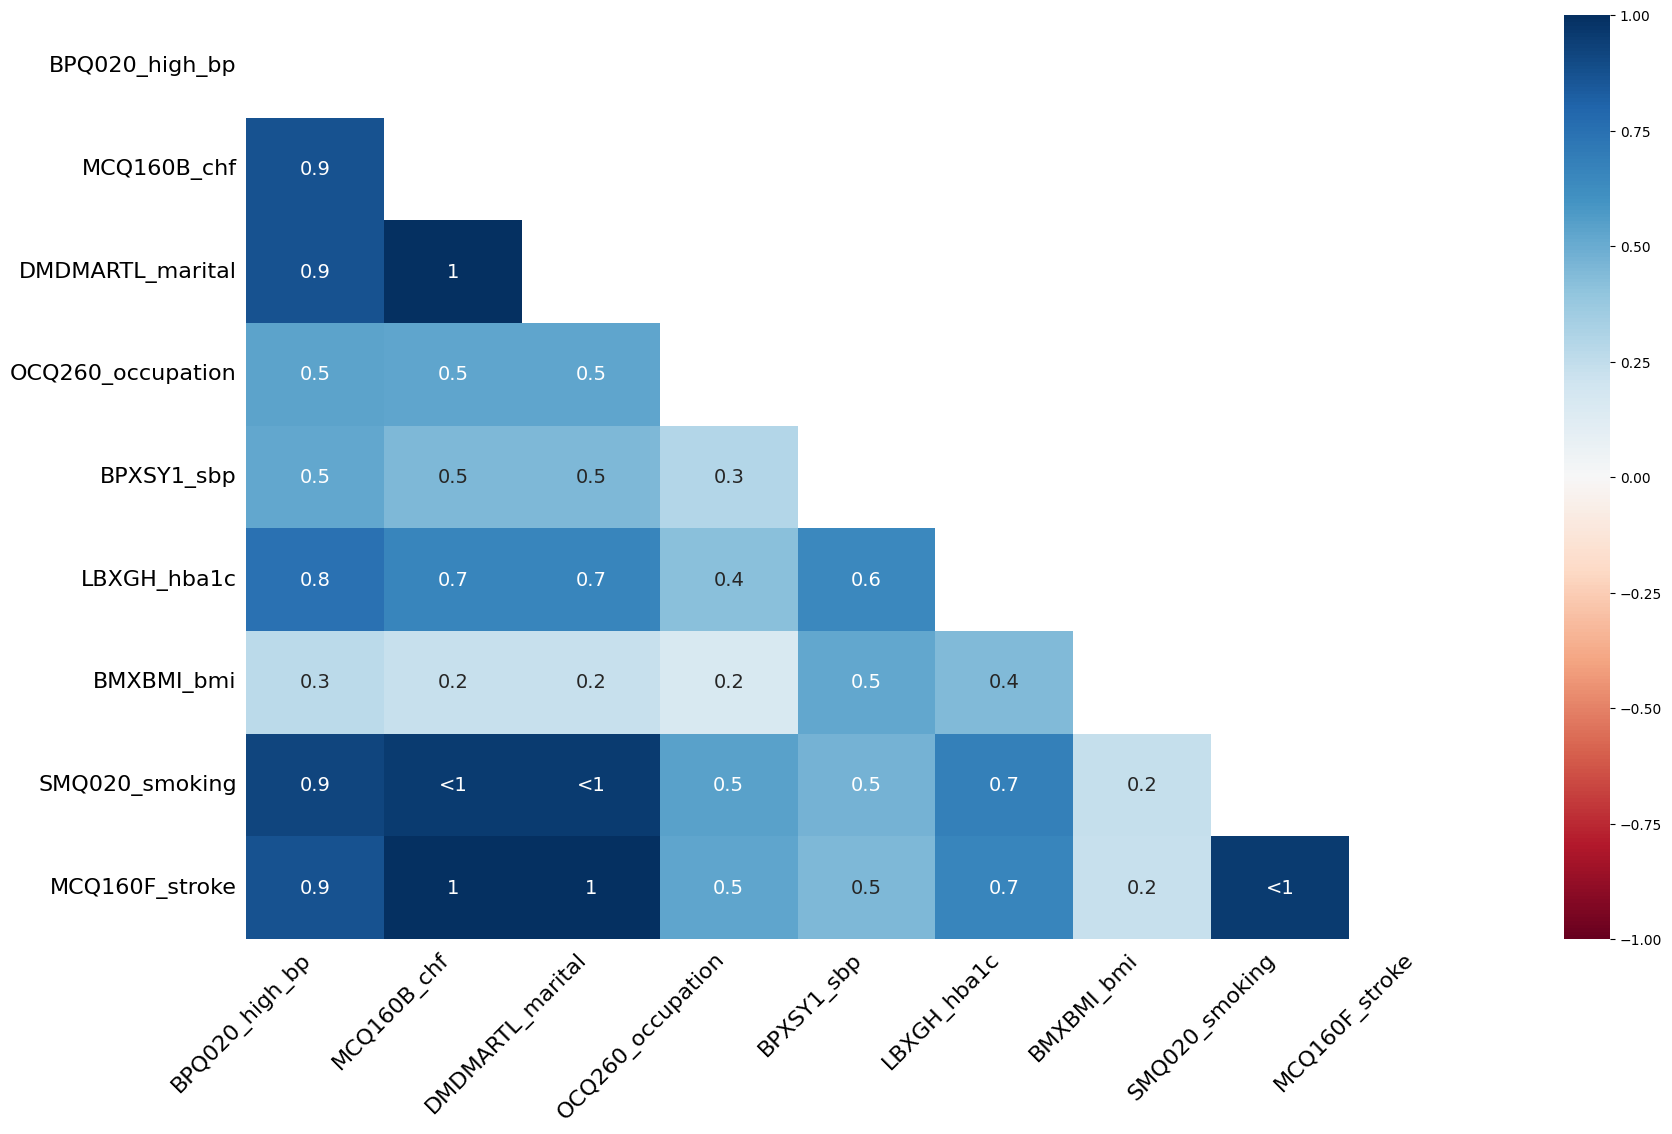

In [ ]:
# visualizar o mapa de calor dos valores ausentes
msno.heatmap(df)

In [ ]:
# Exibir missing por coluna e impacto do dropna
print("Initial shape:", df.shape)

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Missing % per column:\n", missing_pct)

# Não aplicar dropna global; vamos usar imputação no pipeline
print("Final shape (after removing ambiguous codes):", df.shape)





# Verificar valores ambíguos nas variáveis categóricas e no alvo (códigos 7 e 9)
cat_cols = ['BPQ020_high_bp', 'MCQ160B_chf', 'SMQ020_smoking', 'MCQ160F_stroke']

rows_after = df.shape[0]

for c in cat_cols:
    if c in df.columns:
        print(c, "contagens de valor:")
        print(df[c].value_counts(dropna=False))

# Remover códigos ambíguos (7,9) das colunas categóricas e do alvo (se existirem)
amb_cols = [c for c in cat_cols if c in df.columns]
rows_before = df.shape[0]
for c in amb_cols:
    df = df[~df[c].isin([7,9])]
rows_after = df.shape[0]
print(f"Linhas removidas devido a códigos ambíguos. (7/9): {rows_before - rows_after}")

Initial shape: (39156, 12)
Missing % per column:
 OCQ260_occupation    66.002656
MCQ160B_chf          42.241291
MCQ160F_stroke       42.241291
DMDMARTL_marital     42.238737
SMQ020_smoking       39.932577
BPQ020_high_bp       35.831035
LBXGH_hba1c          35.746757
BPXSY1_sbp           30.087343
BMXBMI_bmi           12.100317
RIDAGEYR_age          0.000000
SEQN_id               0.000000
RIAGENDR_gender       0.000000
dtype: float64
Final shape (after removing ambiguous codes): (39156, 12)
BPQ020_high_bp value counts:
BPQ020_high_bp
2.0    16664
NaN    14030
1.0     8432
9.0       30
Name: count, dtype: int64
MCQ160B_chf value counts:
MCQ160B_chf
2.0    21781
NaN    16540
1.0      784
9.0       50
7.0        1
Name: count, dtype: int64
SMQ020_smoking value counts:
SMQ020_smoking
NaN    15636
2.0    13772
1.0     9729
9.0       15
7.0        4
Name: count, dtype: int64
MCQ160F_stroke value counts:
MCQ160F_stroke
2.0    21679
NaN    16540
1.0      913
9.0       23
7.0        1
Name: coun

In [ ]:
# Verificar o DataFrame final
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39038 entries, 0 to 39155
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SEQN_id            39038 non-null  float64
 1   RIAGENDR_gender    39038 non-null  float64
 2   RIDAGEYR_age       39038 non-null  float64
 3   BPQ020_high_bp     25008 non-null  float64
 4   MCQ160B_chf        22500 non-null  float64
 5   DMDMARTL_marital   22501 non-null  float64
 6   OCQ260_occupation  13286 non-null  float64
 7   BPXSY1_sbp         27276 non-null  float64
 8   LBXGH_hba1c        25057 non-null  float64
 9   BMXBMI_bmi         34311 non-null  float64
 10  SMQ020_smoking     23403 non-null  float64
 11  MCQ160F_stroke     22500 non-null  float64
dtypes: float64(12)
memory usage: 3.9 MB


<Axes: >

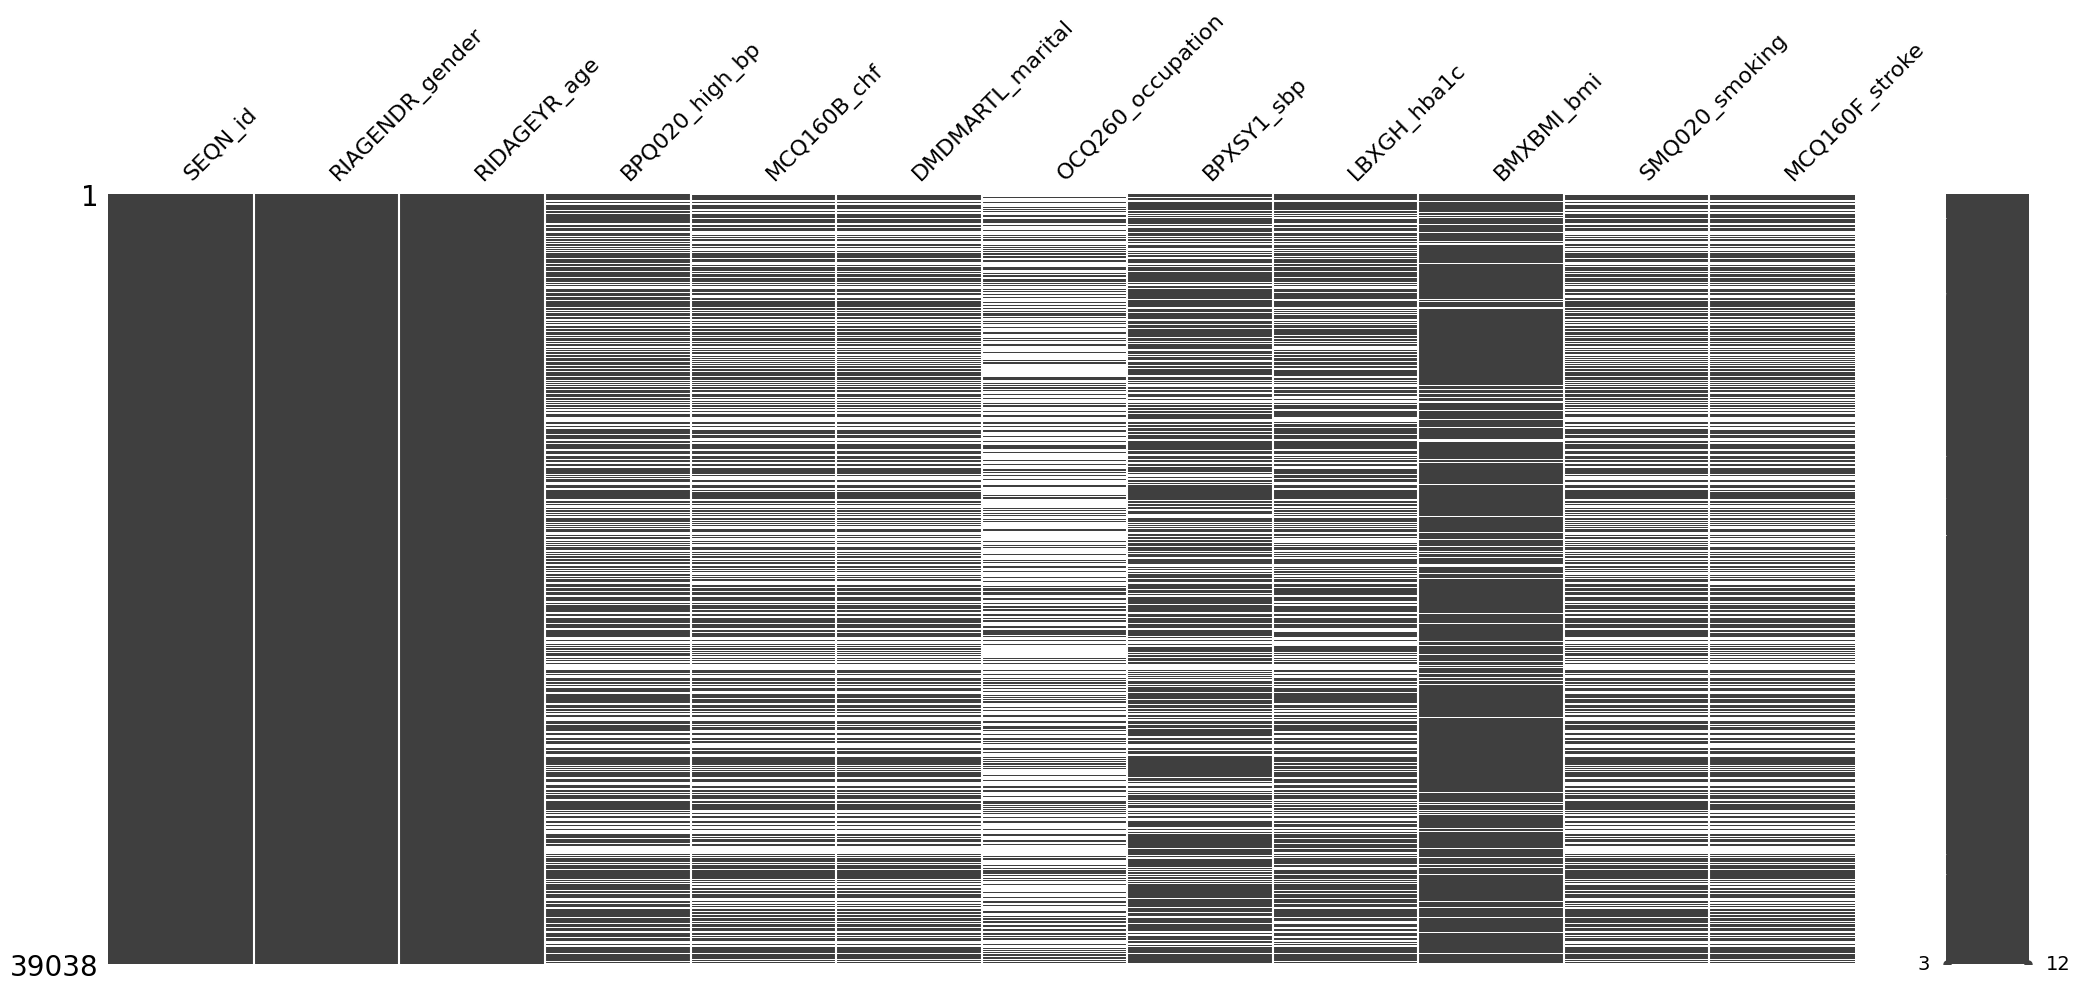

In [ ]:
# visualizar o mapa de calor dos valores ausentes
msno.matrix(df)

In [ ]:
# verificar os valores únicos da coluna alvo (original codes)
target_col = 'MCQ160F_stroke'

if target_col in df.columns:    print("Valores alvo unicos:", sorted(df[target_col].unique()))

Unique target values: [np.float64(2.0), np.float64(nan), np.float64(1.0)]


In [340]:
# Manter só 1 (Yes) e 2 (No) no alvo e criar coluna binária 'MCQ160F_stroke_bin'
target_col = 'MCQ160F_stroke'
if target_col in df.columns:
    df = df[df[target_col].isin([1,2])].copy()
    df['MCQ160F_stroke_bin'] = df[target_col].map({1:1, 2:0})
    print("Counts (1=stroke,0=no):")
    print(df['MCQ160F_stroke_bin'].value_counts())

df.shape

Counts (1=stroke,0=no):
MCQ160F_stroke_bin
0    21601
1      899
Name: count, dtype: int64


(22500, 13)

In [ ]:
# Resumo estatístico das colunas numéricas
df.describe()

,SEQN_id,RIAGENDR_gender,RIDAGEYR_age,BPQ020_high_bp,MCQ160B_chf,DMDMARTL_marital,OCQ260_occupation,BPXSY1_sbp,LBXGH_hba1c,BMXBMI_bmi,SMQ020_smoking,MCQ160F_stroke,MCQ160F_stroke_bin
count,22500.000000,22500.000000,22500.000000,22500.000000,22500.000000,22500.000000,12484.000000,19687.000000,20531.000000,21232.000000,22500.000000,22500.000000,22500.000000
mean,83173.898311,1.516533,49.694933,1.632089,1.965333,2.660978,2.446812,124.870727,5.810267,29.314813,1.574933,1.960044,0.039956
std,11860.529052,0.499738,17.755709,0.482248,0.182938,2.871671,8.224527,18.861486,1.123564,7.141333,0.494364,0.195859,0.195859
min,62161.000000,1.000000,20.000000,1.000000,1.000000,1.000000,1.000000,66.000000,3.500000,13.400000,1.000000,1.000000,0.000000
25%,73715.750000,1.000000,34.000000,1.000000,2.000000,1.000000,1.000000,112.000000,5.300000,24.300000,1.000000,2.000000,0.000000
50%,83677.000000,2.000000,50.000000,2.000000,2.000000,2.000000,1.000000,122.000000,5.500000,28.100000,2.000000,2.000000,0.000000
75%,93536.500000,2.000000,64.000000,2.000000,2.000000,5.000000,2.000000,134.000000,5.900000,32.900000,2.000000,2.000000,0.000000
max,102956.000000,2.000000,80.000000,2.000000,2.000000,99.000000,99.000000,238.000000,17.800000,86.200000,2.000000,2.000000,1.000000


/tmp/ipykernel_43683/1488412930.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='MCQ160F_stroke_bin', y='RIDAGEYR_age', data=df, palette='hls')


<Axes: xlabel='MCQ160F_stroke_bin', ylabel='RIDAGEYR_age'>

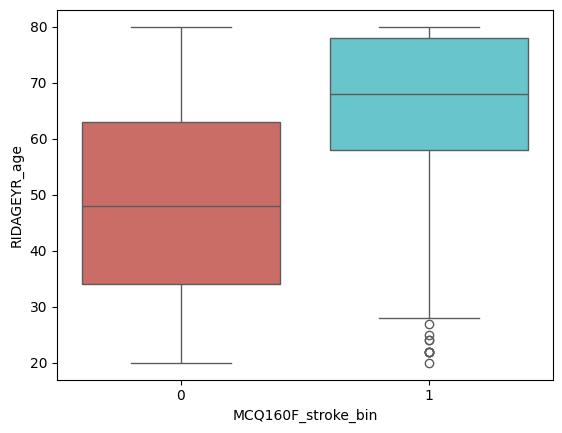

In [342]:
import seaborn as sb

# Visualiza a distribuição de idade entre os pacientes com e sem histórico de derrame
sb.boxplot(x='MCQ160F_stroke_bin', y='RIDAGEYR_age', data=df, palette='hls')

**Analisando as variáveis numéricas**

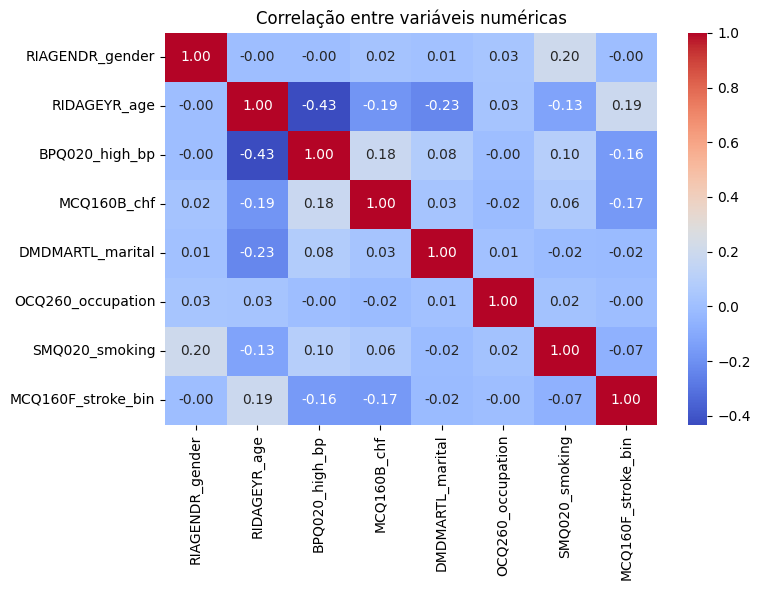

In [343]:
import matplotlib.pyplot as plt

# 1) Heatmap de correlação (numéricas)
num_cols = ['RIAGENDR_gender', 'RIDAGEYR_age', 'BPQ020_high_bp', 'MCQ160B_chf', 'DMDMARTL_marital', 'OCQ260_occupation', 'SMQ020_smoking', 'MCQ160F_stroke_bin']
# Keep only numeric columns for correlation (convert categories to numeric if needed)
corr_df = df[num_cols].copy()
corr_df = corr_df.apply(pd.to_numeric, errors='coerce')
plt.figure(figsize=(8,6))
sb.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre variáveis numéricas')
plt.tight_layout()

plt.show()


/tmp/ipykernel_43683/1030250867.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rate = df.groupby('age_bin')['MCQ160F_stroke_bin'].mean().reset_index()
/tmp/ipykernel_43683/1030250867.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='age_bin', y='MCQ160F_stroke_bin', data=age_rate, palette='viridis')


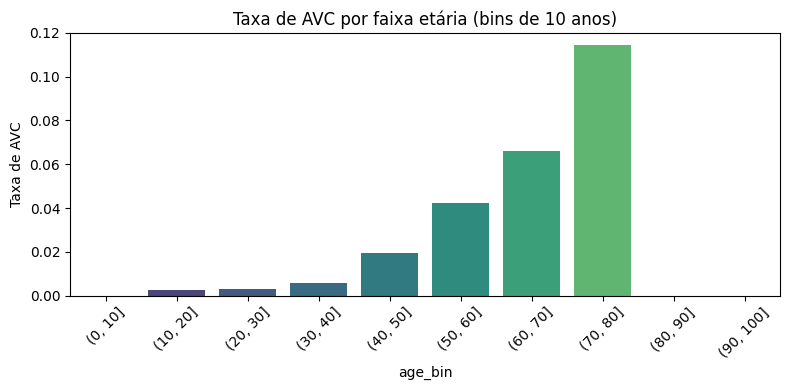

In [ ]:
# Taxa de AVC por faixa etária
df['age_bin'] = pd.cut(df['RIDAGEYR_age'], bins=range(0, 101, 10))
age_rate = df.groupby('age_bin')['MCQ160F_stroke_bin'].mean().reset_index()
plt.figure(figsize=(8,4))
sb.barplot(x='age_bin', y='MCQ160F_stroke_bin', data=age_rate, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel('Taxa de AVC')
plt.title('Taxa de AVC por faixa etária (bins de 10 anos)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_43683/287367880.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=var, y='rate', data=agg, palette='coolwarm')


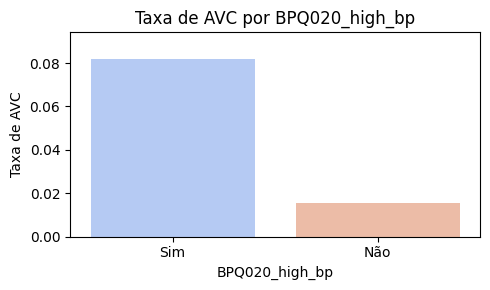

/tmp/ipykernel_43683/287367880.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=var, y='rate', data=agg, palette='coolwarm')


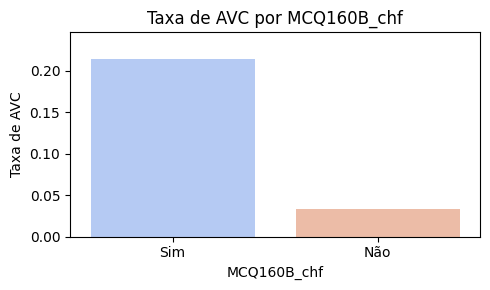

/tmp/ipykernel_43683/287367880.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=var, y='rate', data=agg, palette='coolwarm')


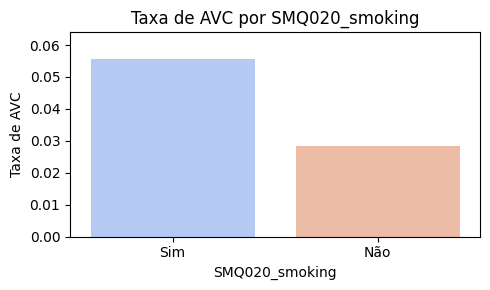

In [345]:
# Taxa de AVC por variáveis categóricas (BPQ020_high_bp, MCQ160B_chf, SMQ020_smoking)
label_map = {1: 'Sim', 2: 'Não'}
for var in ['BPQ020_high_bp', 'MCQ160B_chf', 'SMQ020_smoking']:
    if var in df.columns:
        agg = df.groupby(var)['MCQ160F_stroke_bin'].agg(['count','sum']).reset_index()
        agg['rate'] = agg['sum'] / agg['count']
        plt.figure(figsize=(5,3))
        sb.barplot(x=var, y='rate', data=agg, palette='coolwarm')
        plt.xticks(ticks=range(len(agg[var])), labels=[label_map.get(int(v), v) for v in agg[var]])
        plt.ylim(0, agg['rate'].max()*1.15)
        plt.ylabel('Taxa de AVC')
        plt.title(f'Taxa de AVC por {var}')
        plt.tight_layout()
        plt.show()

===== LogisticRegression =====
              precision    recall  f1-score   support

           0       0.99      0.69      0.81      4320
           1       0.10      0.78      0.17       180

    accuracy                           0.70      4500
   macro avg       0.54      0.73      0.49      4500
weighted avg       0.95      0.70      0.79      4500

ROC AUC: 0.8117830504115225
PR AUC: 0.18047910897367386
Confusion matrix:
 [[2988 1332]
 [  40  140]]
===== RandomForest =====
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      4320
           1       0.20      0.04      0.07       180

    accuracy                           0.95      4500
   macro avg       0.58      0.52      0.52      4500
weighted avg       0.93      0.95      0.94      4500

ROC AUC: 0.7538856738683127
PR AUC: 0.1185968415642612
Confusion matrix:
 [[4287   33]
 [ 172    8]]

Top 10 features by permutation importance (RandomForest, transformed features):
      

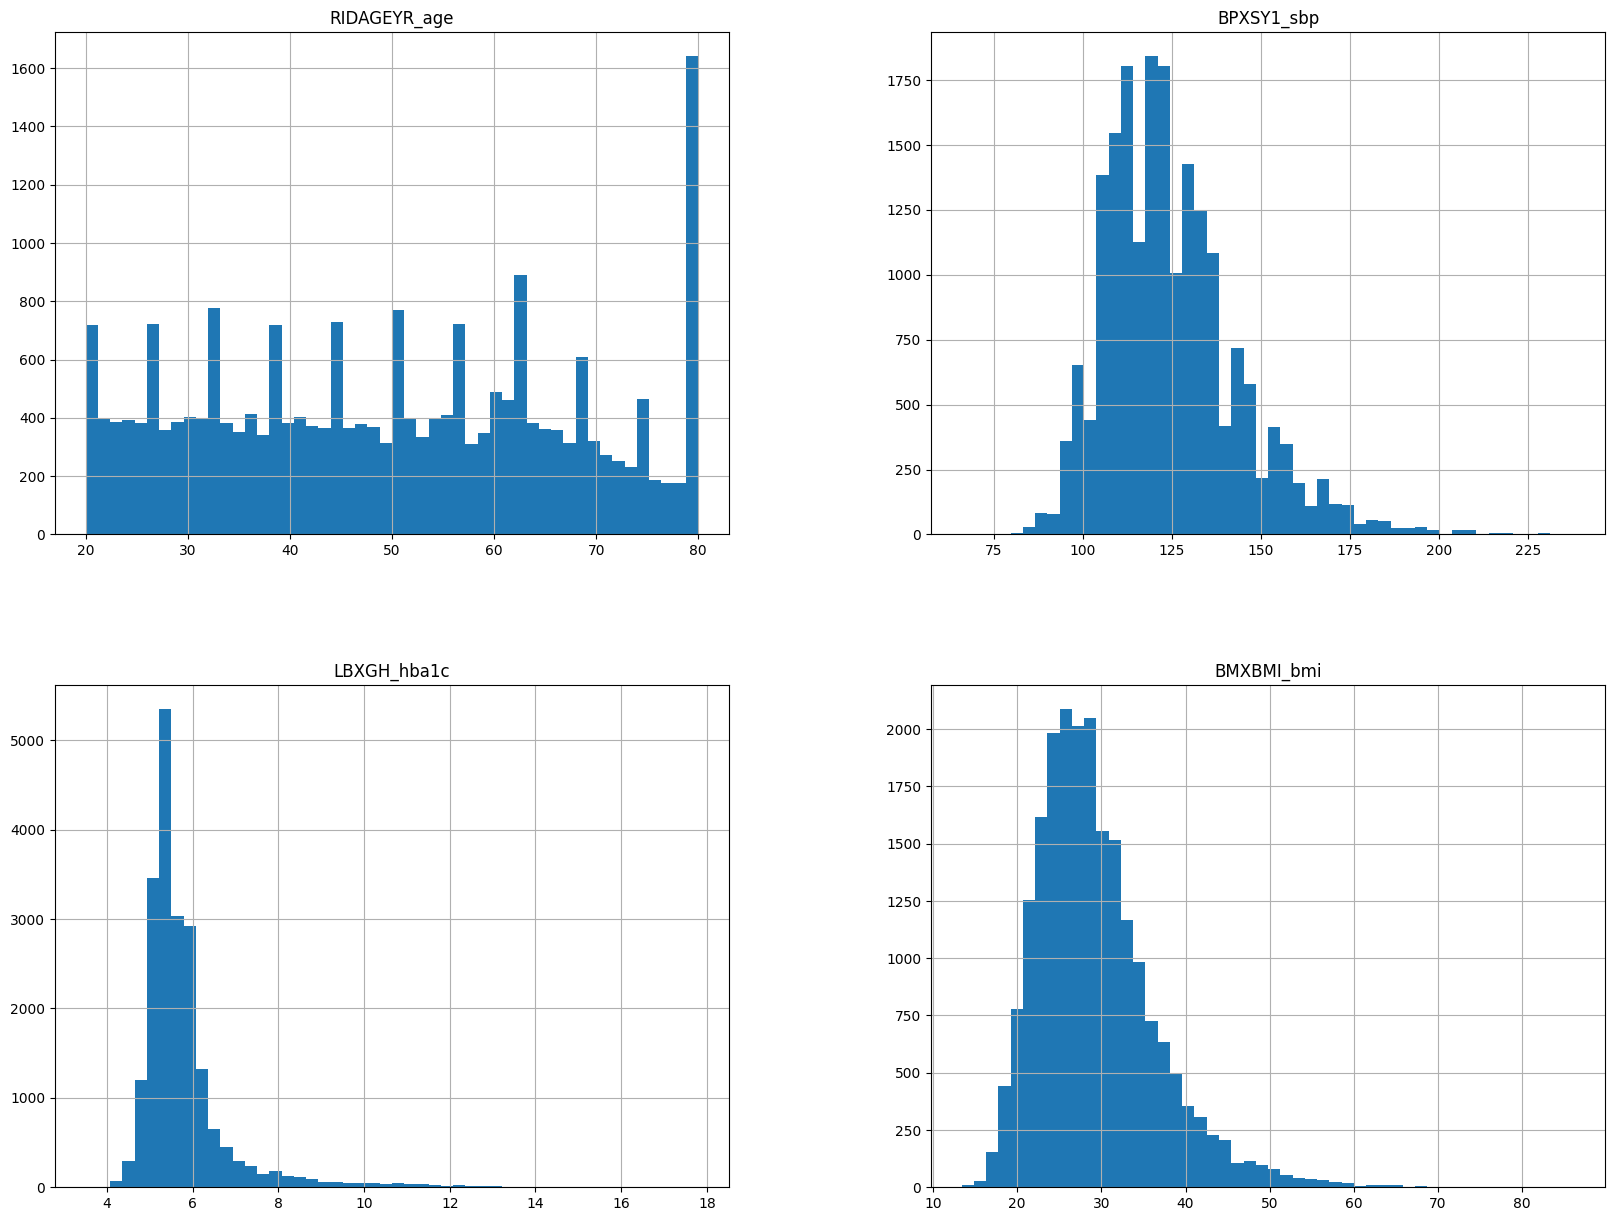

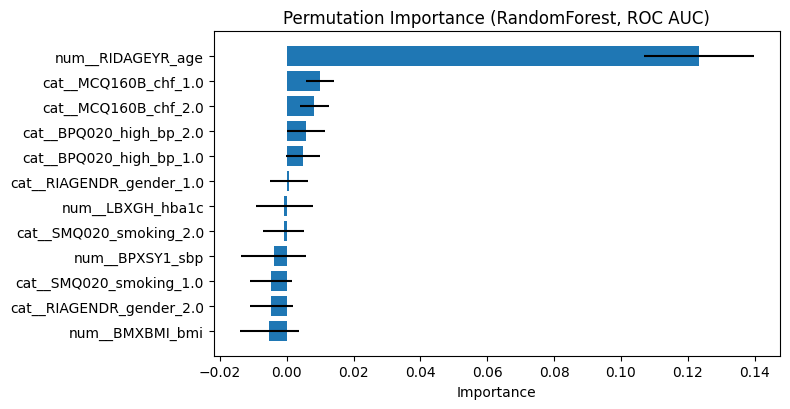

In [ ]:
# Distribuição das variáveis numéricas (selecionadas)
num_hist_cols = ['RIDAGEYR_age', 'BPXSY1_sbp', 'LBXGH_hba1c', 'BMXBMI_bmi']
df[num_hist_cols].hist(bins=50, figsize=(20,15))

# Preprocessing pipeline and baseline models
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix

num_cols = ['RIDAGEYR_age', 'BPXSY1_sbp', 'LBXGH_hba1c', 'BMXBMI_bmi']
cat_cols = ['RIAGENDR_gender', 'BPQ020_high_bp', 'MCQ160B_chf', 'SMQ020_smoking']

# Eliminar linhas com alvo ausente
df_model = df.dropna(subset=['MCQ160F_stroke_bin']).copy()
X = df_model[num_cols + cat_cols]
y = df_model['MCQ160F_stroke_bin']

# Dividir em treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])

preproc = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

pipe_lr = Pipeline([('pre', preproc), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))])
pipe_rf = Pipeline([('pre', preproc), ('clf', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))])

pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# Avaliar os modelos no conjunto de teste
for name, model in [('LogisticRegression', pipe_lr), ('RandomForest', pipe_rf)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred))
    print('ROC AUC:', roc_auc_score(y_test, y_prob))
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    print('PR AUC:', auc(recall, precision))
    print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

# Permutation importance (alternative to SHAP)
from sklearn.inspection import permutation_importance

# Compute permutation importance on the transformed features (after preprocessing)
X_test_trans = preproc.transform(X_test)
r = permutation_importance(pipe_rf.named_steps['clf'], X_test_trans, y_test, n_repeats=30, random_state=42, scoring='roc_auc')
feat_names = preproc.get_feature_names_out()
import pandas as pd
imp_df = pd.DataFrame({'feature': feat_names, 'importance': r.importances_mean, 'std': r.importances_std})
imp_df = imp_df.sort_values('importance', ascending=False)

print('\nAs 10 principais características por importância de permutação (RandomForest, características transformadas):')
print(imp_df.head(10))

# Plot top permutation importances (take top 20 for visibility)
top_k = min(20, len(imp_df))
# Sort ascending for horizontal bar plot (most important at top)
top = imp_df.head(top_k).sort_values('importance', ascending=True)
plt.figure(figsize=(8, max(4, 0.35*top_k)))
plt.barh(top['feature'], top['importance'], xerr=top['std'], color='C0')
plt.xlabel('Importância')
plt.title('Importância da permutação (RandomForest, AUC ROC)')
plt.tight_layout()
plt.show()

## Referências

- https://pandascouple.medium.com/projeto-machine-learning-previs%C3%A3o-de-avc-f4b7dce11929
- https://jornal.usp.br/radio-usp/uso-de-ia-e-analise-de-dados-na-prevencao-de-avc-e-ataque-isquemico-transitorio/
- https://www.nature.com/articles/s41598-024-61665-4?error=cookies_not_supported&code=1d85f26e-6ade-4ec5-9132-5511aa615597&_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc
- https://jhi.sbis.org.br/index.php/jhi-sbis/article/view/980
- https://www.nature.com/articles/s41598-025-01855-w
